# D212 Data Mining II - Segmentation

Desiree McElroy - Clustering Task

------

This report applies k-means clustering to patient data to identify groups of patients with similar demographic and health characteristics. The insights derived from this analysis are intended to support more informed business and strategic decision making across the organization.


## Part I: Research Question

### A1.  Research Question:

This leads to the research question, “What groups of patients share similar demographic and health-related characteristics, and how can identifying these groups help the hospital predict care needs and costs?”

### A2. Goal:

The goal is to identify patient clusters based on clinical and financial indicators to help hospital administrators target resource-intensive patient groups and reduce total charges.

## Part II: Technique Justification

### B1.  Why k-means?

K-means clustering works by iteratively assigning each data point to the nearest centroid based on Euclidean distance (by default), then recalculating centroids as the mean of all points within that cluster. This process repeats until cluster assignments are stable. Because the algorithm relies on distance calculations, it performs best with continuous variables that are on a comparable scale. K-means produces well-separated clusters, making it well suited for identifying distinct patient segments within a healthcare dataset such as this.

Based on the patient data, I expect the clustering to reveal a few distinct patient groups. For example, younger patients with fewer health issues will likely fall into a cluster with shorter hospital stays and lower charges, while older patients with more complex conditions will probably form their own group with longer stays and higher costs. Identifying these groups would give the hospital a clearer picture of which patients require the most resources and where to focus planning efforts


### B2.  K-means assumption:

One assumption of k-means is that clusters are roughly spherical and similar in size. This is because the algorithm assigns each patient to whichever centroid is closest based on Euclidean distance, which works best when the data forms compact, evenly distributed groups. To help meet this assumption, the continuous variables in this dataset are scaled before clustering so that features with larger ranges don't unfairly dominate the distance calculations.

### B3.  Libraries:

1. pandas — used to load and clean the dataset, including renaming columns, setting the index, and selecting only the continuous variables needed for clustering.

1. numpy — supports the numerical operations used throughout the preprocessing and modeling steps.

1. scikit-learn — provides the main tools for this analysis: KMeans for clustering, RobustScaler for scaling the data, and silhouette_score for measuring how well the clusters turned out.

1. matplotlib — used to create the elbow plot and feature boxplots, which help determine the right number of clusters and compare the groups visually.

1. seaborn — used for distribution plots and boxplots during the data exploration phase.

In [1]:
# imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import preprocess

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

# modeling
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', None)
import warnings
warnings.filterwarnings('ignore')

## Part III: Data Preparation

### C1. Preprocessing goal relevant to clustering:

The primary preprocessing goal for this analysis is to scale the continuous variables so that features with larger numeric ranges do not disproportionately influence the clustering results. For example, variables like total_charges and income have ranges in the tens of thousands, while a variable like age ranges from roughly 18 to 89. Without scaling, k-means would effectively weight the larger-range features more heavily when calculating distances, which would produce misleading clusters. 

To address this, scaling was explored and applied selectively, only to features with notably wider ranges. Scaling variables that are more discrete in nature (such as children or doc_visits) can reduce natural separation between groups and introduce ambiguity in the cluster results.


### C2. Variables to use (continuous only):

The analysis uses only the continuous variables from the dataset, as k-means clustering requires numeric input and performs best with features that vary across a meaningful range. The ten variables selected are listed below, each labeled as continuous:

    'population',
    'children',
    'age',
    'income',
    'vitd_levels',
    'doc_visits',
    'full_meals_eaten',
    'length_of_stay',
    'total_charges',
    'additional_charges'

  
### C3. Steps used to prepare the data:

The following steps were taken to prepare the data for clustering. The code segment for each step is shown below:

**1. Column normalization and renaming:**
 
Column names were lowercased for consistency, and three columns were renamed to improve readability.

```python
df.columns = df.columns.str.lower()
df.rename(columns={
    'totalcharge': 'total_charges',
    'initial_days': 'length_of_stay',
    'caseorder': 'case_order'
}, inplace=True)
df.set_index('case_order', inplace=True)
```

**2. Subset to continuous variables:**
The dataset was filtered to retain only the ten continuous features listed in C2, dropping all categorical and identifier columns.

```python
continuous_columns = [
    'population', 'children', 'age', 'income', 'vitd_levels',
    'doc_visits', 'full_meals_eaten', 'length_of_stay',
    'total_charges', 'additional_charges'
]
df = df[continuous_columns]
```

**3. Assess missing values:**

No missing values were found across any of the 10 variables, so no imputation or row removal was necessary.


**4. Scale features:**

Both `StandardScaler` and `RobustScaler` were explored and evaluated. The winning model showed partial robust scaling produced the strongest silhouette scores. `RobustScaler` was applied selectively to the four variables with notably wider numeric ranges. The remaining six features were left unscaled to preserve their natural distribution and maintain cluster separation. 


**5. Export cleaned dataset:**  
The preprocessed (unscaled) dataset was exported to a CSV file for submission. The scaled version is reconstructed in the analysis section.

### C4. Cleaned data set:

The cleaned dataset contains 10,000 patient records across the 10 continuous variables identified in C2. It was exported as `medical_clean_prepared.csv` and is included as a separate file with this submission.

#### Acquisition

In [2]:
# from preprocess script
df = preprocess.preprocess_df()
df.info()

original dataframe shape: (10000, 50)
new dataframe shape: (10000, 10)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 10000 entries, 1 to 10000
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   population          10000 non-null  int64  
 1   children            10000 non-null  int64  
 2   age                 10000 non-null  int64  
 3   income              10000 non-null  float64
 4   vitd_levels         10000 non-null  float64
 5   doc_visits          10000 non-null  int64  
 6   full_meals_eaten    10000 non-null  int64  
 7   length_of_stay      10000 non-null  float64
 8   total_charges       10000 non-null  float64
 9   additional_charges  10000 non-null  float64
dtypes: float64(5), int64(5)
memory usage: 859.4 KB


No nulls to address luckily. Data is already appropriate numerical type.

In [3]:
# export cleaned dataset for clustering task
df.to_csv('medical_clean_prepared.csv')
print('Cleaned dataset saved: medical_clean_prepared.csv')

Cleaned dataset saved: medical_clean_prepared.csv


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
population,10000.0,9965.253800,14824.758614,0.000000,694.750000,2769.000000,13945.000000,122814.000000
children,10000.0,2.097200,2.163659,0.000000,0.000000,1.000000,3.000000,10.000000
age,10000.0,53.511700,20.638538,18.000000,36.000000,53.000000,71.000000,89.000000
income,10000.0,40490.495160,28521.153293,154.080000,19598.775000,33768.420000,54296.402500,207249.100000
vitd_levels,10000.0,17.964262,2.017231,9.806483,16.626439,17.951122,19.347963,26.394449
doc_visits,10000.0,5.012200,1.045734,1.000000,4.000000,5.000000,6.000000,9.000000
full_meals_eaten,10000.0,1.001400,1.008117,0.000000,0.000000,1.000000,2.000000,7.000000
length_of_stay,10000.0,34.455299,26.309341,1.001981,7.896215,35.836244,61.161020,71.981490
total_charges,10000.0,5312.172769,2180.393838,1938.312067,3179.374015,5213.952000,7459.699750,9180.728000
additional_charges,10000.0,12934.528587,6542.601544,3125.703000,7986.487755,11573.977735,15626.490000,30566.070000


**Viewing Distributions**

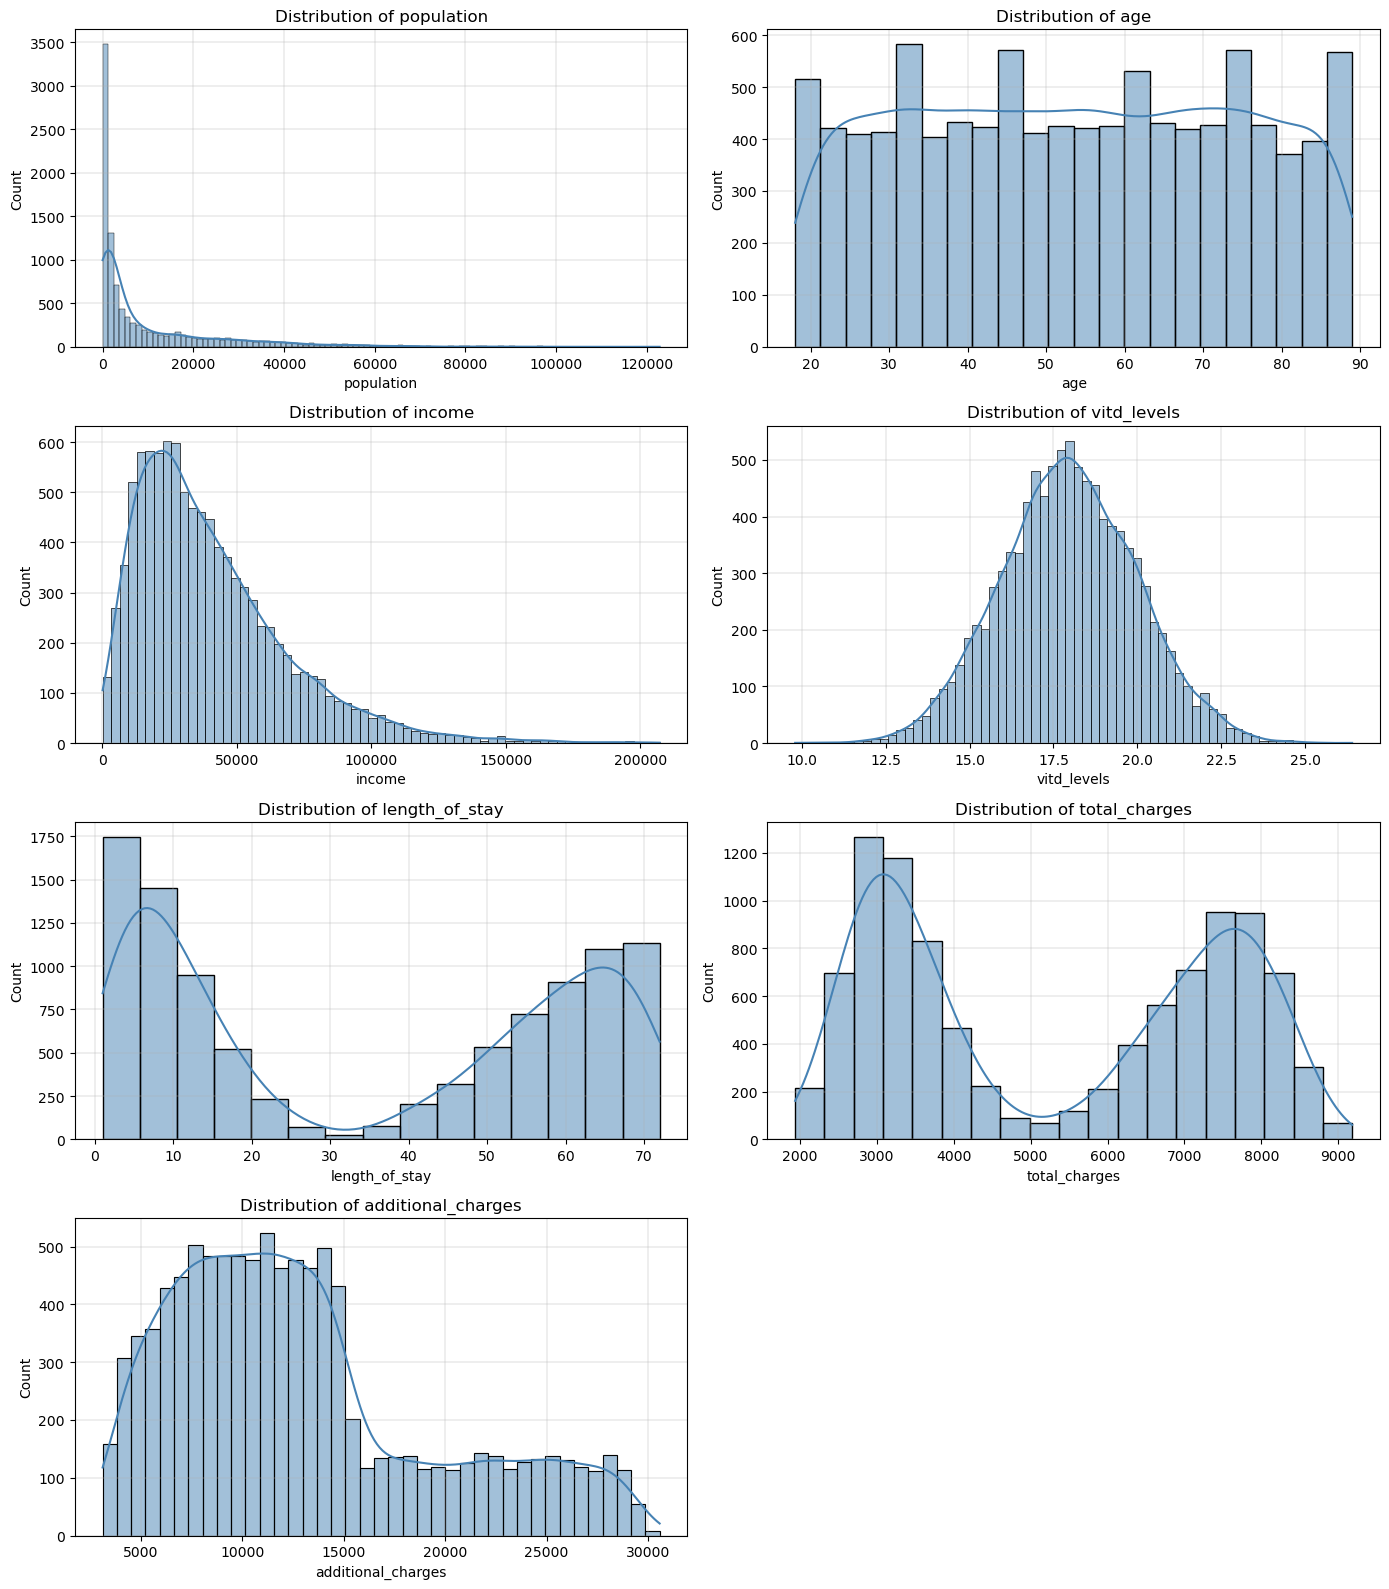

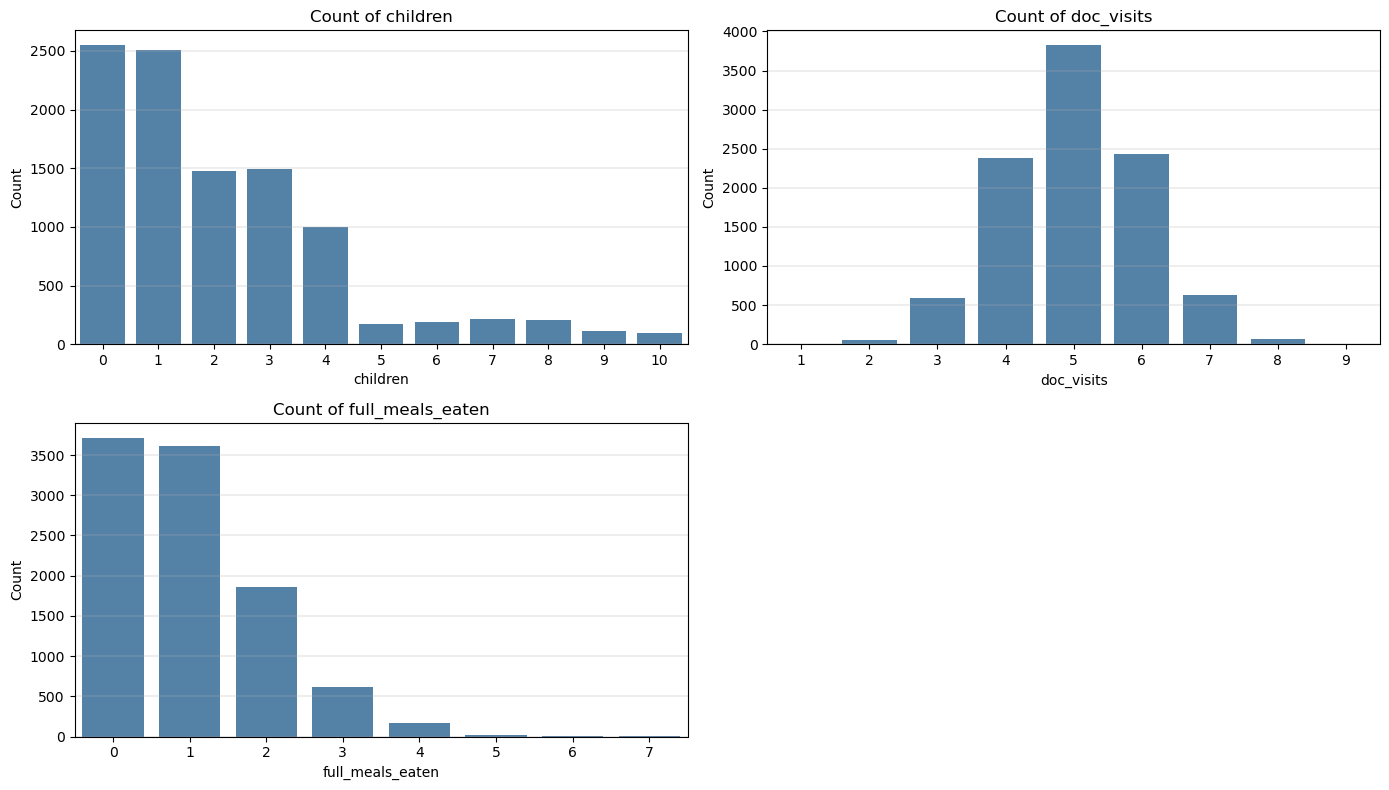

In [5]:
## larger ranges require different plot type
distribution_view = [
    'population',
    'age',
    'income',
    'vitd_levels',
    'length_of_stay',
    'total_charges',
    'additional_charges',
]

## smaller ranges require different plot types
count_view = [
    'children',
    'doc_visits',
    'full_meals_eaten',
]

# distribution plots (2-column grid)
n_cols = 2
n_rows = -(-len(distribution_view) // n_cols) 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for ax, col in zip(axes, distribution_view):
    sns.histplot(df[col], kde=True, color='steelblue', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.grid(linewidth=0.3)

for ax in axes[len(distribution_view):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# count/bar plots (2-column grid)
n_rows_c = -(-len(count_view) // n_cols)

fig, axes = plt.subplots(n_rows_c, n_cols, figsize=(14, n_rows_c * 4))
axes = axes.flatten()

for ax, col in zip(axes, count_view):
    counts = df[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, color='steelblue', ax=ax)
    ax.set_title(f'Count of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.grid(linewidth=0.3, axis='y')

for ax in axes[len(count_view):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


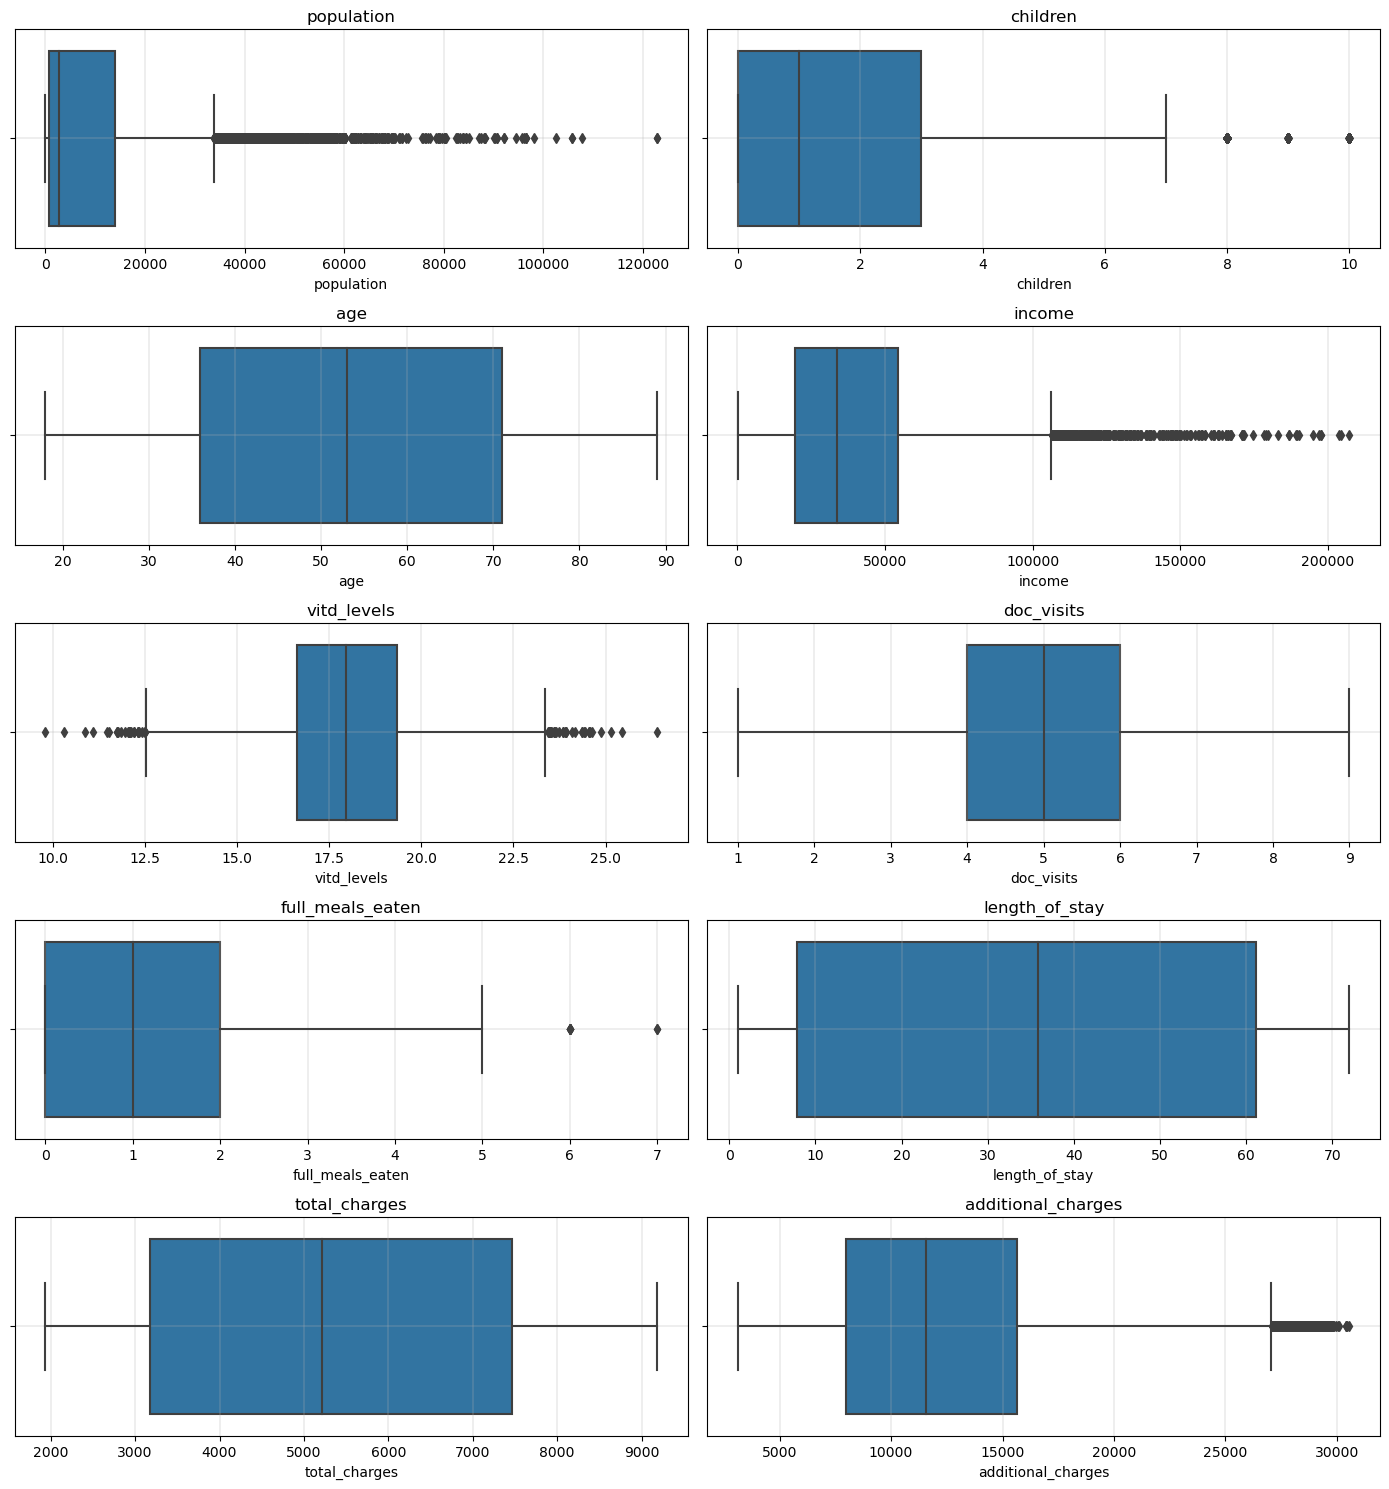

In [6]:
# boxplots to view IQR details and outliers
cols = list(df.columns)
n_cols = 2
n_rows = -(-len(cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.grid(linewidth=0.3)

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## Part IV: Analysis

### D1. Determining the Optimal Number of Clusters

To determine the optimal number of clusters, two complementary methods were used: the elbow method and the silhouette score. This approach was taken after also exploring various scaling strategies and feature groupings to ensure the final cluster count reflected meaningful structure in the data rather than an artifact of preprocessing choices.

**Elbow Method (WCSS)**

The elbow method evaluates clustering quality by plotting the "Within Cluster Sum of Squares" (WCSS) against the number of clusters. WCSS, accessed via `km.inertia_` in scikit-learn's `KMeans`, measures the sum of squared Euclidean distances from each observation to its assigned cluster centroid:

$$\text{WCSS} = \sum_{i=1}^{n} \| x_i - \mu_{k(i)} \|^2$$

where $\mu_{k(i)}$ is the centroid of the cluster assigned to point $x_i$. As the number of clusters increases, WCSS decreases. The optimal number of clusters is identified at the "elbow", the point where adding more clusters produces diminishing reductions in WCSS.

**Silhouette Score**

To validate the elbow result, the silhouette score was calculated for each candidate cluster count. The silhouette score measures how similar each observation is to its own cluster compared to neighboring clusters, and ranges from -1 to +1. A score closer to +1 indicates that observations are matched well to their assigned cluster and clearly separated from other clusters. The cluster count that produced both a visible elbow and the highest silhouette score was selected as the optimal value.



D2.  **Provide the code used to perform the clustering analysis technique.**

Code provided within notebook below.

#### Scaling

**Scaling All Variables**


Starting with the Standard Scaler.

Using Standard Scaler
Silhouette Scores:
Num Clusters 2 Silhouette score: 0.1858
Num Clusters 3 Silhouette score: 0.144
Num Clusters 4 Silhouette score: 0.1337
Num Clusters 5 Silhouette score: 0.1362
Num Clusters 6 Silhouette score: 0.1394
Num Clusters 7 Silhouette score: 0.1388
Num Clusters 8 Silhouette score: 0.1328
Num Clusters 9 Silhouette score: 0.1243
Num Clusters 10 Silhouette score: 0.1133
Num Clusters 11 Silhouette score: 0.1143


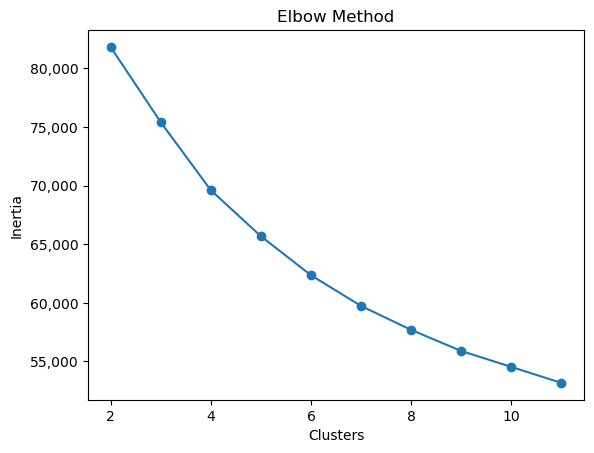

In [7]:
# scale
scaler = StandardScaler()
print('Using Standard Scaler')


X_scaled = scaler.fit_transform(df)

# scaled df
scaled_df = pd.DataFrame(X_scaled, columns=df.columns)# ## Scaling

print('Silhouette Scores:')
for i in range(2,12):
    # silhouette example
    km = KMeans(n_clusters=i, random_state=42).fit(scaled_df)
    labels = km.labels_
    score = silhouette_score(scaled_df, labels)
    print(f'Num Clusters {i} Silhouette score: {round(score,4)}')

# elbow method
inertia = []
for k in range(2,12):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(scaled_df)
  inertia.append(km.inertia_)

plt.title('Elbow Method')
plt.plot(range(2,12), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.show()

This elbow plot does not show a clear influx point. Additionally, higher cluster counts (e.g. more than 12 in this scenario) would reduce interpretability and provide diminishing practical value for stakeholders.

**Robust Scaler**

Using Robust Scaler
Silhouette Scores:
Num Clusters 2 Silhouette score: 0.2616
Num Clusters 3 Silhouette score: 0.1559
Num Clusters 4 Silhouette score: 0.1524
Num Clusters 5 Silhouette score: 0.1451
Num Clusters 6 Silhouette score: 0.1504
Num Clusters 7 Silhouette score: 0.1437
Num Clusters 8 Silhouette score: 0.1283
Num Clusters 9 Silhouette score: 0.1201
Num Clusters 10 Silhouette score: 0.1194
Num Clusters 11 Silhouette score: 0.1126


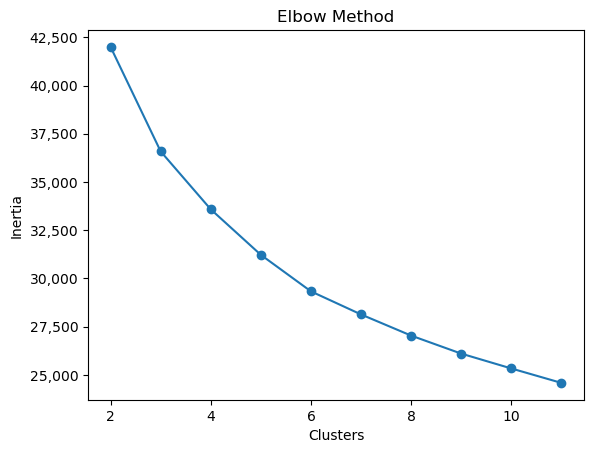

In [8]:
scaler = RobustScaler()
print('Using Robust Scaler')
scaled_df = scaler.fit_transform(df)

print('Silhouette Scores:')
for i in range(2,12):
    # silhouette example
    km = KMeans(n_clusters=i, random_state=42).fit(scaled_df)
    labels = km.labels_
    score = silhouette_score(scaled_df, labels)
    print(f'Num Clusters {i} Silhouette score: {round(score,4)}')


# elbow method
inertia = []
for k in range(2,12):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(scaled_df)
  inertia.append(km.inertia_)

plt.title('Elbow Method')
plt.plot(range(2,12), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.show()

Scaling all features with RobustScaler does improve silhouette scores compared to StandardScaler, but the scores are still low and the elbow is weak. My next hypothesis is to apply the scaler to a subset of features, particularly those with a large larger range and leave the rest of the features unscaled.


While K-means typically requires scaling of all variables, selective scaling is explored to evaluate whether preserving the natural range of lower range features improves cluster interpretability.

#### Exploring Partial Columns Scaled

Using Robust Scaler on only ['population', 'income', 'total_charges', 'additional_charges']
With partial scaled columns
Silhouette Scores:
Num Clusters 2 Silhouette score: 0.5223
Num Clusters 3 Silhouette score: 0.4889
Num Clusters 4 Silhouette score: 0.5067
Num Clusters 5 Silhouette score: 0.46
Num Clusters 6 Silhouette score: 0.409
Num Clusters 7 Silhouette score: 0.3736
Num Clusters 8 Silhouette score: 0.3339
Num Clusters 9 Silhouette score: 0.3503
Num Clusters 10 Silhouette score: 0.3433
Num Clusters 11 Silhouette score: 0.3443


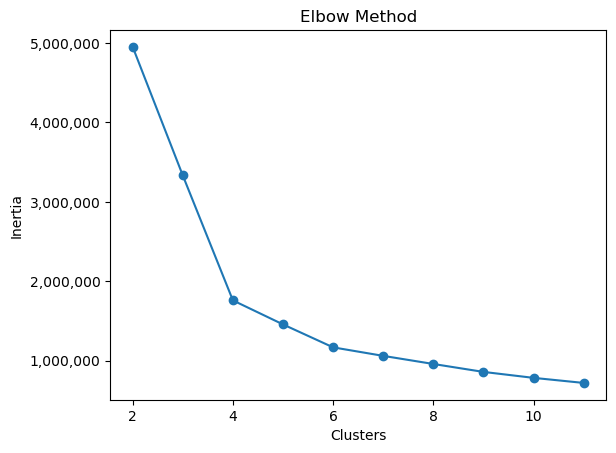

In [9]:
wider_range_cols = [
    'population',
    'income',
    'total_charges',
    'additional_charges'
]

# scale only wider range columns
scaler = RobustScaler()
print(f'Using Robust Scaler on only {(wider_range_cols)}')

scaled_wide = pd.DataFrame(
    scaler.fit_transform(df[wider_range_cols]),
    columns=wider_range_cols,
    index=df.index
)

# merge scaled columns back, replacing originals
scaled_df = df.drop(columns=wider_range_cols).join(scaled_wide)

# scaled_df.head()


print('With partial scaled columns')
print('Silhouette Scores:')
for i in range(2,12):
    # silhouette example
    km = KMeans(n_clusters=i, random_state=42).fit(scaled_df)
    labels = km.labels_
    score = silhouette_score(scaled_df, labels)
    print(f'Num Clusters {i} Silhouette score: {round(score,4)}')


# elbow method
inertia = []
for k in range(2,12):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(scaled_df)
  inertia.append(km.inertia_)

plt.title('Elbow Method')
plt.plot(range(2,12), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.show()

Scaling only a subset of columns is showing much better signal. This approach resulted in stronger silhouette scores and clearer cluster separation.

Using Robust Scaler on only ['population', 'income', 'total_charges', 'additional_charges', 'length_of_stay']
With partial scaled columns
Silhouette Scores:
Num Clusters 2 Silhouette score: 0.5866
Num Clusters 3 Silhouette score: 0.5161
Num Clusters 4 Silhouette score: 0.4619
Num Clusters 5 Silhouette score: 0.4194
Num Clusters 6 Silhouette score: 0.3804
Num Clusters 7 Silhouette score: 0.3451
Num Clusters 8 Silhouette score: 0.3164
Num Clusters 9 Silhouette score: 0.2868
Num Clusters 10 Silhouette score: 0.2608
Num Clusters 11 Silhouette score: 0.2391


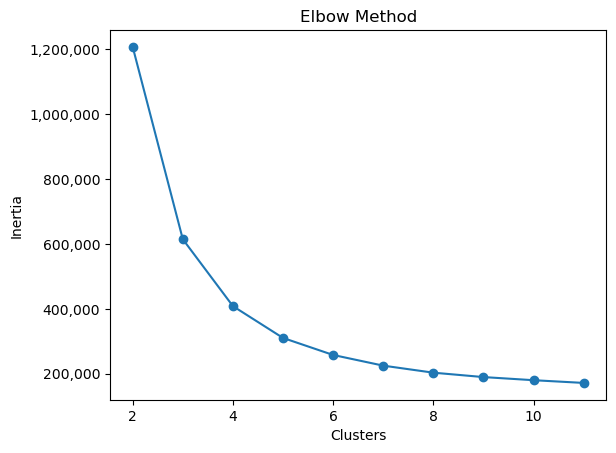

In [10]:
wider_range_cols = [
    'population',
    'income',
    'total_charges',
    'additional_charges',
    'length_of_stay',
]

# scale only wider range columns
scaler = RobustScaler()
print(f'Using Robust Scaler on only {(wider_range_cols)}')

scaled_wide = pd.DataFrame(
    scaler.fit_transform(df[wider_range_cols]),
    columns=wider_range_cols,
    index=df.index
)

# merge scaled columns back, replacing originals
scaled_df = df.drop(columns=wider_range_cols).join(scaled_wide)

print('With partial scaled columns')
print('Silhouette Scores:')
for i in range(2,12):
    # silhouette example
    km = KMeans(n_clusters=i, random_state=42).fit(scaled_df)
    labels = km.labels_
    score = silhouette_score(scaled_df, labels)
    print(f'Num Clusters {i} Silhouette score: {round(score,4)}')


# elbow method
inertia = []
for k in range(2,12):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(scaled_df)
  inertia.append(km.inertia_)

plt.title('Elbow Method')
plt.plot(range(2,12), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.show()

#### Final Model Selection

Using Robust Scaler on only ['population', 'income', 'total_charges', 'additional_charges']
k=2  inertia=4,950,132  silhouette=0.5223
k=3  inertia=3,331,540  silhouette=0.4889
k=4  inertia=1,758,952  silhouette=0.5067
k=5  inertia=1,456,619  silhouette=0.46
k=6  inertia=1,167,727  silhouette=0.409
k=7  inertia=1,060,559  silhouette=0.3736
k=8  inertia=958,446  silhouette=0.3339
k=9  inertia=858,649  silhouette=0.3503
k=10  inertia=783,707  silhouette=0.3433
k=11  inertia=719,929  silhouette=0.3443


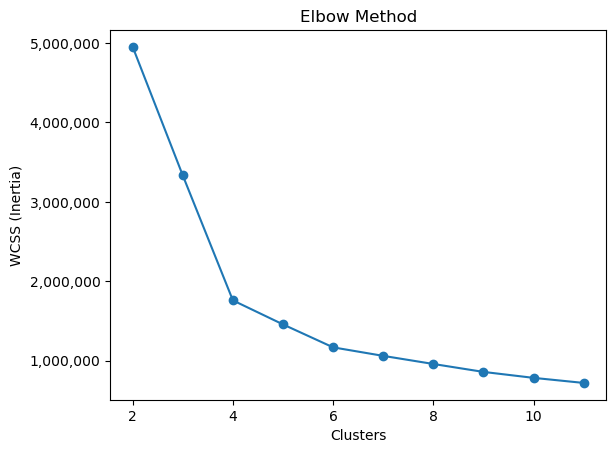


Final model  k=4  silhouette=0.5067


population                        children                   \
                 mean  median           std      mean median       std   
cluster                                                                  
0        10314.517983  2971.0  15378.026755  2.102424      1  2.198514   
1         9876.833466  2615.0  14812.968424  2.012321      1  2.065971   
2         9613.200645  2615.0  14118.019624  2.088235      1  2.160217   
3        10048.250409  2885.5  14947.161844  2.188216      2  2.225464   

               age                          income                           \
              mean median        std          mean     median           std   
cluster                                                                       
0        36.400313     36  10.515684  39839.287647  33519.850  27808.017846   
1        35.434420     35  10.388099  41333.671069  33909.805  29128.053097   
2        71.182917     71  10.488914  40134.519923  34022.210  28196.807141   
3        72.085106     72   9.965399  40665.572398  33709.380  28945.263456   

        vitd_levels                      doc_visits                   \
               mean     median       std       mean median       std   
cluster                                                                
0         17.932354  17.901185  2.024032   4.999609      5  1.042507   
1         17.930014  17.888838  2.012078   4.996423      5  1.030541   
2         18.025985  18.008651  1.978349   5.051168      5  1.060542   
3         17.970231  17.982105  2.053879   5.002046      5  1.049139   

        full_meals_eaten                  length_of_stay                       \
                    mean median       std           mean     median       std   
cluster                                                                         
0               0.987881      1  1.010818      59.694137  61.198485  8.628688   
1               1.007949      1  0.993786       9.122968   7.927373  5.991178   
2               1.029412      1  1.021110       9.313054   7.840364  6.229739   
3               0.980360      1  1.006540      59.650984  61.108520  8.576409   

        total_charges                          additional_charges  \
                 mean       median         std               mean   
cluster                                                             
0         7374.797375  7456.782000  790.045681        9086.084415   
1         3236.621708  3172.766710  593.484725        8818.290290   
2         3257.256643  3183.236564  618.715525       17022.211347   
3         7376.900489  7464.688500  779.283965       17048.745912   

                                    
               median          std  
cluster                             
0         8145.063500  3910.532702  
1         7913.318558  3805.541505  
2        14376.258615  6215.064691  
3        14237.700000  6179.827865

In [11]:
wider_range_cols = [
    'population',
    'income',
    'total_charges',
    'additional_charges'
]


# scale only wider range columns
scaler = RobustScaler()
print(f'Using Robust Scaler on only {(wider_range_cols)}')

scaled_wide = pd.DataFrame(
    scaler.fit_transform(df[wider_range_cols]),
    columns=wider_range_cols,
    index=df.index
)

# merge scaled columns back, replacing originals
scaled_df = df.drop(columns=wider_range_cols).join(scaled_wide)

# scaled_df.head()


# elbow + silhouette scan
inertia, sil_scores = [], []
for k in range(2, 12):
    km = KMeans(n_clusters=k, random_state=42).fit(scaled_df)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_df, km.labels_))
    print(f'k={k}  inertia={km.inertia_:,.0f}  silhouette={round(silhouette_score(scaled_df, km.labels_), 4)}')

plt.title('Elbow Method')
plt.plot(range(2, 12), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS (Inertia)")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.show()

# final model: k=4
N_CLUSTERS = 4
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42).fit(scaled_df)
print(f'\nFinal model  k={N_CLUSTERS}  silhouette={round(silhouette_score(scaled_df, km_final.labels_), 4)}')

# cluster profiling dataframe (unscaled values + cluster label)
cluster_df = df.copy()
cluster_df['cluster'] = km_final.labels_
profile = cluster_df.groupby('cluster').agg(['mean', 'median', 'std'])
profile

#### Profiling Winning Clusters

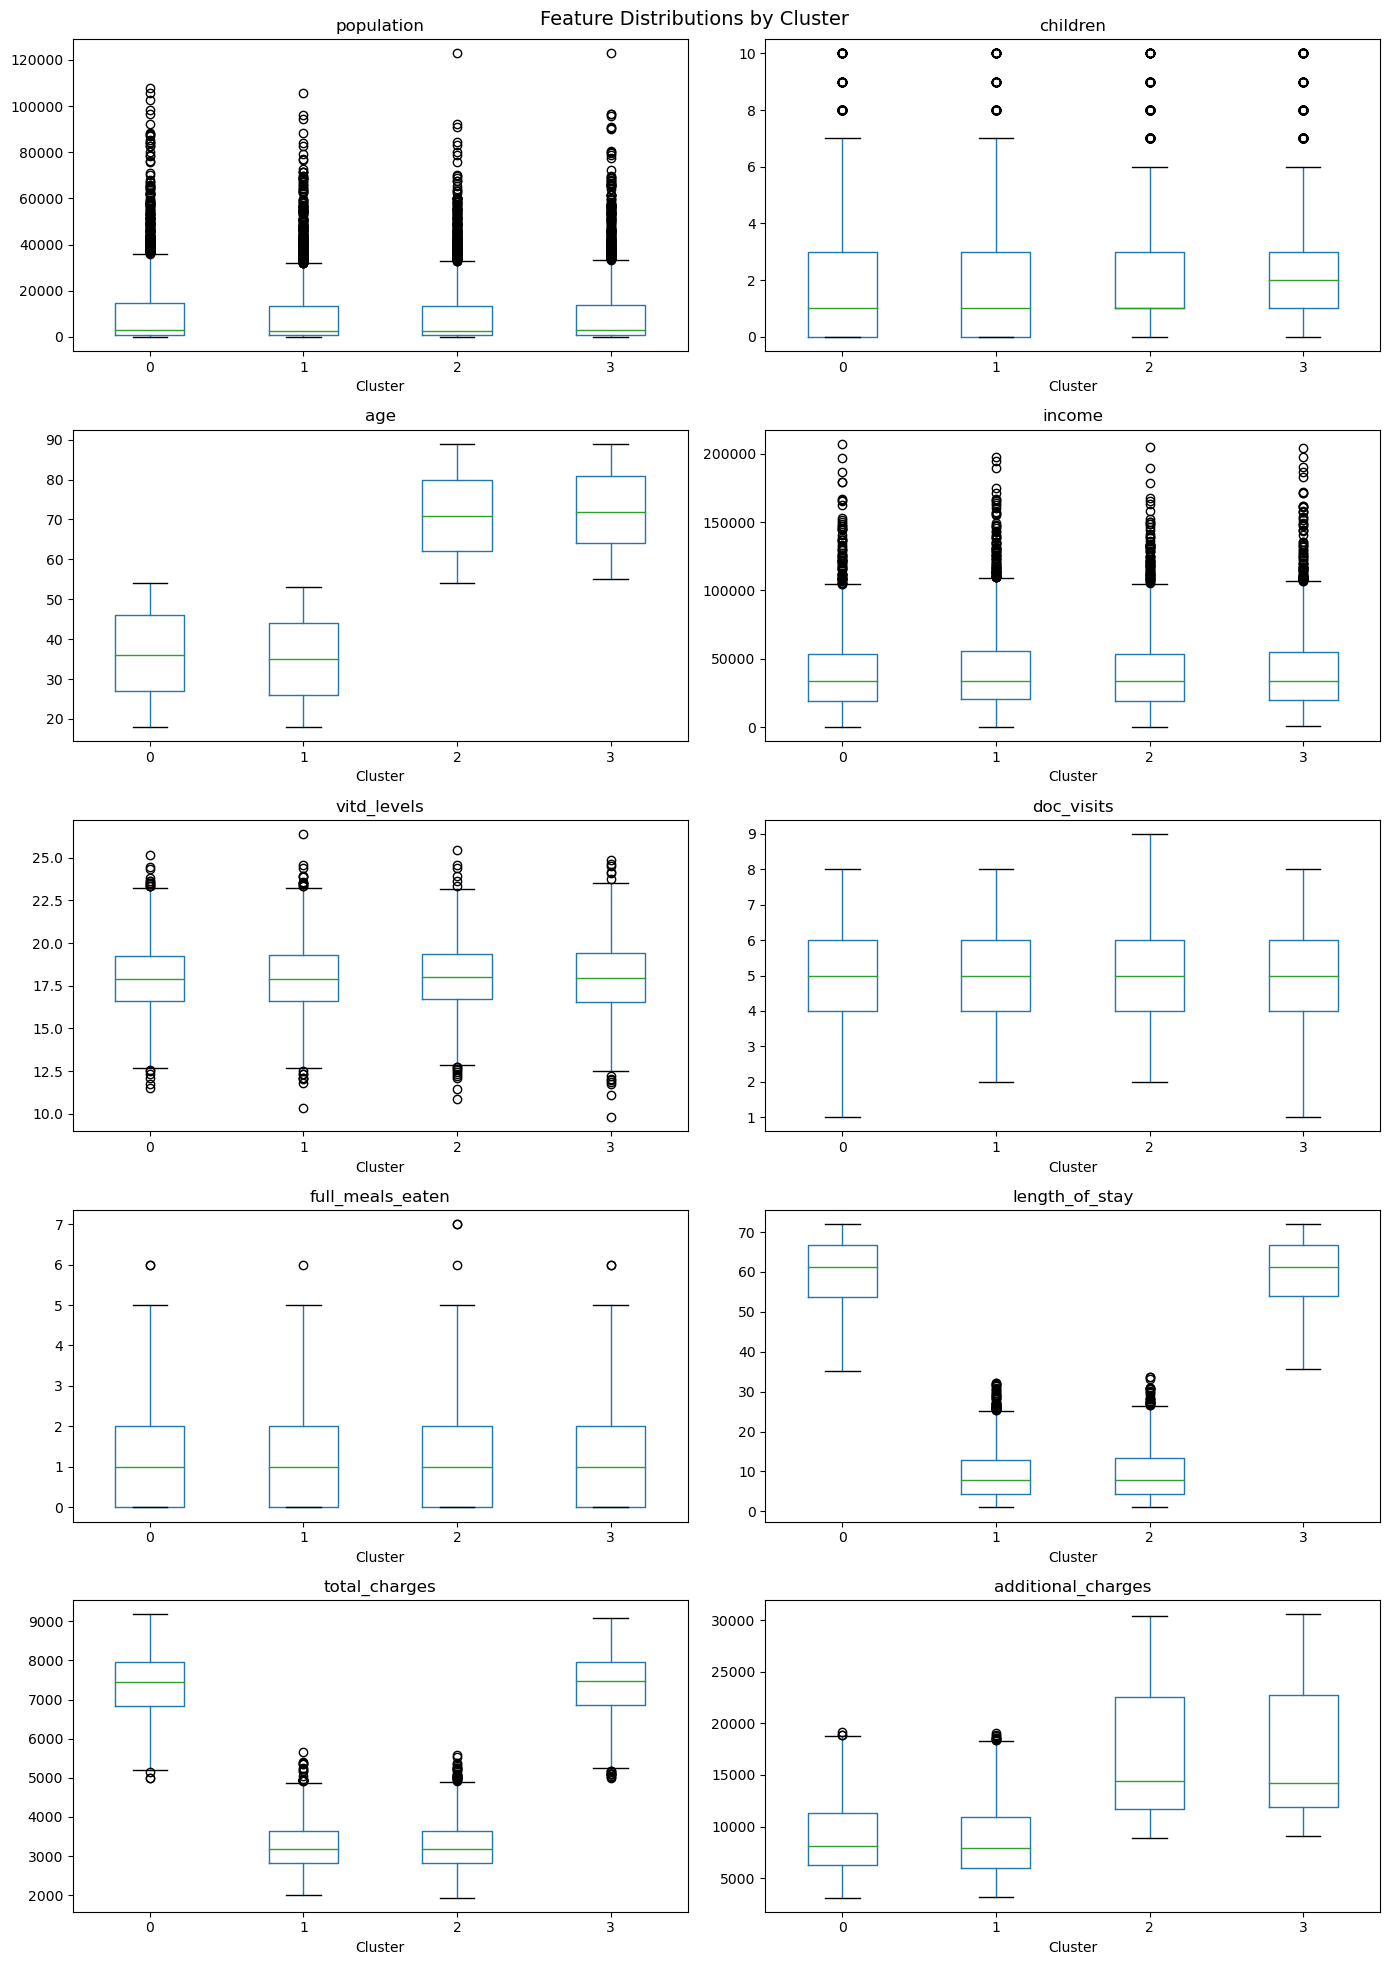

In [12]:
# get all feature columns (excluding cluster label)
features = [c for c in cluster_df.columns if c != 'cluster']

# set up a 2-column grid layout
n_cols = 2
n_rows = -(-len(features) // n_cols)  # ceiling division: ensures enough rows for all features

# create the grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))

# flatten from 2D array to 1D to loop over axes one at a time
axes = axes.flatten()

# draw one boxplot per feature, with all 4 clusters shown side by side
for ax, feat in zip(axes, features):
    cluster_df.boxplot(column=feat, by='cluster', ax=ax, grid=False)
    ax.set_title(feat)       # label each subplot with the feature name
    ax.set_xlabel('Cluster') # x-axis shows cluster number
    ax.set_ylabel('')        # no y-axis label needed (feature name is in title)

# if grid has more cells than features, hide the leftover empty subplots
for ax in axes[len(features):]:
    ax.set_visible(False)

fig.suptitle('Feature Distributions by Cluster', fontsize=14)
plt.tight_layout()
plt.show()

## Part V: Data Summary & Implications

### E1. Cluster Quality

The quality of the four cluster solution was evaluated using two complementary metrics: silhouette score and the WCSS elbow plot. The final model at k=4 produced a silhouette score of 0.51, which showed to be the highest value among cluster counts tested (k=2 through k=11). The WCSS elbow plot also shows a visible inflection point at k=4, with diminishing returns beyond that point.

The clusters are primarily distinguished by four variables: `age`, `length_of_stay`, `total_charges`, and `additional_charges`. These features show the clearest separation across the boxplots and cluster profile means. Variables such as `vitd_levels`, `doc_visits`, and `full_meals_eaten` show little variation across clusters and contribute less to cluster profiling. The features `children`, `income`, and `population` show moderate separation and provide secondary context to the cluster profiles.

The structure of the four segments reflects two independent axes of variation: patient age (younger, ~36 years vs. older, ~71 years) and length of hospital stay (short, ~9 days vs. long, ~60 days). Additional charges track closely with age, with older patients carrying roughly twice the additional charges of younger patients, regardless of stay length. The four resulting clusters are summarized below.

| Cluster | Label | Key Characteristics |
|---------|-------|---------------------|
| 0 | Young, long-stay, moderate costs | Young patients (~36 yrs), long stays (~60 days), high total charges, lower additional charges |
| 1 | Young, short-stay, low costs | Young patients (~35 yrs), short stays (~9 days), low total and additional charges |
| 2 | Older, short-stay, high additional costs | Older patients (~71 yrs), short stays (~9 days), low total charges, high additional charges |
| 3 | Older, long-stay, highest overall cost | Older patients (~72 yrs), long stays (~60 days), high total charges, high additional charges |

---

### E2. Results and Implications

**Cluster 0** represents younger patients with extended hospital stays and high total charges, but whose additional charges remain in the lower range (~$9,100). Their cost is driven by stay duration rather than additional services.

**Cluster 1** is the lowest cost group: young patients with short stays and limited spending across both charge types. These cases are likely the least clinically complex and likely require the fewest resources.

**Cluster 2** is notable because despite short stays comparable to Cluster 1, these older patients accumulate nearly twice the additional charges (~$17,000 vs. ~$9,000). This likely reflects age-related comorbidities driving ancillary services upward even during brief admissions.

**Cluster 3** represents the highest overall utilization, combining long stays with high charges on both dimensions. These are the oldest patients with the most complex and resource-intensive care profiles.

The analysis indicates that patient cost and care intensity are shaped by two independent features: length of stay, which drives total charges, and patient age, which drives additional charges. These dimensions are operating independently. Older patients incurr high additional charges regardless of stay length, while long stays produce high total charges regardless of age. This has implications for resource allocation. Strategies focused solely on reducing stay length may not address the additional charges burden carried by older patients. In the end, each cluster likely requires a distinct care management approach to reduce costs effectively.

---

### E3. Limitations

One limitation of this analysis is that k-means clustering assumes clusters are roughly spherical and similar in size, which may not accurately reflect the actual structure of the patient population. In data, groups are often unevenly distributed and vary significantly in density. If the true clusters are non-convex or imbalanced, k-means can distort boundaries between groups, assigning some patients to less than optimal clusters. 

The four-cluster solution was selected as the best available option, but the boundaries between clusters should be interpreted with caution, particularly between Clusters 0 and 1, which share similar age profiles, as well as Clusters 2 and 3, which share similar ages but different lengths in stay.

---

### E4. Recommended Course of Action

Based on the cluster results, my recommendation would be for the hospital to prioritize targeted care management programs for patients within different segments. Cluster 3 for example, contains older individuals with long stays and high additional charges. This group shows the highest resource utilization and likely the greatest opportunity for cost reduction through methods such as proactive intervention and proactive case management to reduce unnecessary long stays.

For Cluster 2, the hospital should investigate which specific additional services are driving elevated charges during some short stays. Understanding whether these charges are clinically necessary or reflect inefficiencies could improve savings without compromising care.

Cluster 1 represents the lowest-cost, least-complex patient profile and is a reasonable baseline for benchmarking care efficacy. Cluster 0, while younger, still incurrs high total charges from extended stays. Coordinated care and discharge planning targeting this group could also show measurable savings without requiring more intensive case management warranted by Clusters 2 and 3.

**References**

scikit-learn developers. (n.d.). *Selecting the number of clusters with silhouette analysis on KMeans clustering*. scikit-learn. https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

The Deep Hub. (n.d.). *Implementing K-means clustering from scratch*. Medium. https://medium.com/thedeephub/implementing-k-means-clustering-from-scratch-ed60faace2e6

Wikipedia contributors. (n.d.). *K-means clustering*. Wikipedia. https://en.wikipedia.org/wiki/K-means_clustering